Open a Open-X Embodiment (OxE) dataset

* Goal:
    * Open OxE dataset.
    * Inspect its content.
    * Plot: images, time series of actions, etc.
    * Save a subpart of it (5%) in hdf5 format.
    * Open hdf5 saved file -> Explore whether the format is the same as TFDS format.
    * Mix two datasets.

* environment: oxe_download
* OxE datasets: https://robotics-transformer-x.github.io/

In [97]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import numpy as np

import tensorflow_datasets as tfds
import tensorflow as tf

## Load a dataset

<b>Notes</b>:

* dataset = builder.as_dataset(split="train[:N]") -> selects N episodes from the builder.
* dataset.take(Nn) -> Take Nn episodes from the outer pool of N episodes.

<b>builder_dir</b>:
 
* All listed datasets in: https://docs.google.com/spreadsheets/d/1rPBD77tk60AEIGZrGSODwyyzs5FgCU9Uz3h-3_t2A9g/edit?gid=0#gid=0
* gs://gresearch/robotics/<dataset_name>/<version>
    * dataset_name: name in the column S (of the excel sheet) labeled "_Registered Dataset Name_"
    * version:
        * Most datasets: 0.1.0
        * robo_net: 1.0.0
        * language_table: 0.0.1
        * droid: 1.0.0 or 1.0.1
* Examples used:
    * "gs://gresearch/robotics/bridge/0.1.0"

* Action space: Datasets can represent absolute value, the delta change, or the velocity of the dimension

In [106]:
# builder_dir = "gs://gresearch/robotics/ucsd_kitchen_dataset_converted_externally_to_rlds/0.1.0"
# builder_dir = "gs://gresearch/robotics/robo_net/0.1.0"

def open_dataset(builder_dir: str, size: int, verbose=True):
    builder = tfds.builder_from_directory(
        builder_dir=builder_dir
    )

    # Metadata — features, splits, size, description
    # print("====================================================")
    # print(f"Dataset info:\n\n{builder.info}")

    # Just the feature spec (very useful for Bridge since it's a nested dict:
    # observation/action/reward/etc. per step, grouped into episodes)
    print("====================================================")
    action_metadata = builder.info.features['steps']['action'].doc.desc
    if verbose: print(f"Dataset info features actions:\n\n{action_metadata}")
    if isinstance(step['action'],dict):
        if verbose: print(f"Dataset info features actions:\n\n{builder.info.features['steps']['action']['world_vector']}")
        print(action_metadata)

    dataset = builder.as_dataset(split=f"train[:{size}]")
    print(f"Data size on disk: {builder.info.dataset_size / 1e9:.2f} GB") # GB
    return dataset, action_metadata

data_name_lst = [
    "stanford_hydra_dataset_converted_externally_to_rlds",
    "taco_play"
] # datasets characteristics: Franka, Single Arm, EEF Position.

data_lst = [open_dataset(builder_dir=f"gs://gresearch/robotics/{data_name}/0.1.0",size=1)[0] for data_name in data_name_lst]

Dataset info features actions:

Robot action, consists of [3x EEF positional delta, 3x EEF orientation delta in euler angle, 1x close gripper].
Data size on disk: 77.83 GB
Dataset info features actions:


Data size on disk: 51.29 GB


## Inspect data

<b>Notes</b>:

##### Bridge dataset
| Key | Value |
|---|---|
| Episode | `dict_keys(['steps'])` |
| Step | `dict_keys(['action', 'is_first', 'is_last', 'is_terminal', 'observation', 'reward'])` |
| Observation | `dict_keys(['image', 'natural_language_embedding', 'natural_language_instruction', 'state'])` |
| Action | `dict_keys(['open_gripper', 'rotation_delta', 'terminate_episode', 'world_vector'])` |

---

| Key | Meaning |
|---|---|
| world_vector | `The translation part of the action: a 3D vector [dx, dy, dz] representing how much to move the end-effector, expressed in the world/base frame (not the camera or gripper's local frame)` |
| rotation_delta | `The rotation part of the action: how much to rotate the end-effector, usually as a 3-element delta (roll, pitch, yaw) or axis-angle representation, also relative to world/base frame` |
| open_gripper | `Boolean/scalar gripper command — whether to open (vs. close) the gripper at this timestep` |
| terminate_episode | `Flag/scalar indicating whether the policy is signaling "I'm done with the task now" — distinct from is_last/is_terminal at the step level, which mark the actual end of the recorded trajectory` |

* Structure: Episode -> Steps -> Observations/Actions.
* More on dataset format: https://github.com/google-research/rlds#dataset-format

In [ ]:
# Pull one episode and look at its structure

def _print_keys_values_dataset(data, data_name: str):
    print(f"\n\nDataset: {data_name}")
    for episode in data.take(1):
        print(f"Episode keys: \t\t{episode.keys()}")
        print(f"Number of steps: \t{len(episode['steps'])}")
        for step in episode["steps"].take(1):
            print(f"Step keys: \t\t{step.keys()}")
            print(f"is_first: \t\t{step['is_first']}")
            print(f"is_last: \t\t{step['is_last']}")
            print(f"is_terminal: \t\t{step['is_terminal']}")
            print(f"reward: \t\t{step['reward']}")
            
            
            print("\n================== Observation ========================")
            print(f"Observation keys: \t{step['observation'].keys()}")
            for key_obs in list(step['observation'].keys()):
                print(f"================== {key_obs}")
                print(step['observation'][key_obs])
                print("\n")

            print("========================================================================")
            print("\n\n================== Action ========================")
            if isinstance(step['action'],dict):
                print(f"Action keys: \t\t{step['action'].keys()}")
                for key_act in list(step['action'].keys()):
                    print(f"================== {key_act}")
                    print(step['action'][key_act])
                    print("\n")
            else:
                print(f"Action: \t\t{step['action'].numpy()}")

            print("\n=========================== Step end ===================================")
            print("========================================================================")
        
        print("=========================== Episode end ===================================")
        print("========================================================================\n")

In [94]:
for idx, data in enumerate(data_lst): _print_keys_values_dataset(data, data_name=data_name_lst[idx])



Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode keys: 		dict_keys(['episode_metadata', 'steps'])
Number of steps: 	549
Step keys: 		dict_keys(['action', 'discount', 'is_dense', 'is_first', 'is_last', 'is_terminal', 'language_embedding', 'language_instruction', 'observation', 'reward'])
is_first: 		True
is_last: 		False
is_terminal: 		False
reward: 		0.0

================== Observation ========================
Observation keys: 	dict_keys(['image', 'state', 'wrist_image'])
True
================== image
tf.Tensor(
[[[ 36  36  29]
  [ 35  35  28]
  [ 33  33  31]
  ...
  [ 86  82  80]
  [ 83  82  80]
  [ 86  84  82]]

 [[ 36  35  31]
  [ 35  34  29]
  [ 31  32  30]
  ...
  [ 86  82  80]
  [ 83  81  81]
  [ 83  81  81]]

 [[ 39  35  33]
  [ 37  33  31]
  [ 33  32  30]
  ...
  [ 82  81  79]
  [ 83  82  80]
  [ 83  82  80]]

 ...

 [[170 203 234]
  [177 210 241]
  [169 202 233]
  ...
  [ 91 132 166]
  [ 97 133 168]
  [ 96 132 167]]

 [[174 207 244]
  [163 196 234]
  [15

## Plot dataset

#### Image

* Take episode 1.
* Take all steps in episode 1.
* Plot an image per step.

In [ ]:
def _plot_image_from_dataset(data, data_name: str):
    print(f"\n\nDataset: {data_name}")
    n_steps = len(next(iter(data.take(1)))["steps"])
    print(f"length episode 1: {n_steps}")
    if n_steps > 50:
        n_steps = 50 # Put a maximum of steps per episode, in case there are a lot of them.

    for episode in data.take(1):
        for step in episode["steps"].take(n_steps):
            if "image" in step['observation'].keys():
                img = step["observation"]["image"]
                plt.imshow(img.numpy())
                plt.show()
            else:
                img = step["observation"]["rgb_gripper"] #  rgb_gripper or rgb_static
                plt.imshow(img.numpy())
                plt.show()

In [ ]:
idx = 1
_plot_image_from_dataset(data_lst[idx], data_name = data_name_lst[idx])

#### Action sequence

In [ ]:
for episode in dataset.take(1):
    rotation_delta, world_vector = np.zeros(shape=(n_steps,3)), np.zeros(shape=(n_steps,3))
    idx = 0
    for step in episode["steps"].take(n_steps):
        print(f"idx: {idx} --- \t\t\t --- {step['action']['rotation_delta'].numpy()}")
        rotation_delta[idx,:] = step["action"]["rotation_delta"].numpy()
        world_vector[idx,:] = step["action"]["world_vector"].numpy()
        idx += 1

In [ ]:
'''TODO: 
    - add labels and titles:
        -- x_label: steps.
        -- y_label: units of world vector and rotation_delta --> TODO: look at this.
        -- subtitles: each dimensions corresponding to each component of world vector and rotation delta.
'''

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(9,5))

for dim in range(3):
    ax[0,dim].scatter(np.arange(n_steps), rotation_delta[:,dim])
    ax[1,dim].scatter(np.arange(n_steps), world_vector[:,dim])

fig.tight_layout()
plt.show()

#### Action histogram

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(9,5))

for dim in range(3):
    ax[0,dim].hist(rotation_delta[:,dim])
    ax[1,dim].hist(world_vector[:,dim])

fig.tight_layout()
plt.show()

## Save a fraction of dataset

<b>Notes</b>:

* dataset.save() vs builder.download_and_prepare():
    * dataset.save() is a much lighter, TF-native way to freeze a specific slice or transformed pipeline to disk quickly, but it loses TFDS-level metadata like dataset_size, feature descriptions, citation, etc.
    * download_and_prepare() gives the whole  dataset back in TFDS's own format (portable, versioned, reloadable with all metadata).
* Save hdf5:
    * Goal: Upload dataset with environments that does not contain Tensorflow (tensorflow can have incompatible libraries with pytorch).

In [148]:
def _get_candidate_keys(dimension: str):
    # Get keys for actions and images depending on datasets

    if dimension == "image":
        return ["image", "rgb_gripper", "rgb_static"]
    elif dimension == "action":
        return ["actions", "rotation_delta", "world_vector"]

    # TODO: Incorporate a ValueError loop -> dimension has to be "image" or "action"
    

In [ ]:
#### save data slice as hdf5

# transform into hdf5 format. Useful for uploading with an environment without tensorflow.
def save_hdf5_dataset(path_data: str, data_name_lst: list):
    with h5py.File(f"{path_data}/combined_datasets.h5", "w") as f:
        for data_name in data_name_lst:
            print("\n\n====================================================")
            print(f"Dataset: {data_name}")
            dataset, action_metadata = open_dataset(builder_dir=f"gs://gresearch/robotics/{data_name}/0.1.0", size=1, verbose=False)
            dataset_grp = f.create_group(f"{data_name}")

            for i, episode in enumerate(dataset.take(1)):
                grp_episode = dataset_grp.create_group(f"episode_{i}")
                steps = list(episode["steps"])

                # Collect across all steps first
                candidate_image_keys = _get_candidate_keys(dimension="image") # keys that might contain images.
                grp_images = grp_episode.create_group("images")
                for key in candidate_image_keys:
                    if key in steps[0]['observation'].keys():
                        images = np.stack([s["observation"][key].numpy() for s in steps])
                        grp_images.create_dataset(key, data=images)

                
                grp_action = grp_episode.create_group("actions")
                if isinstance(steps[0]["action"], dict):
                    candidate_action_keys = _get_candidate_keys(dimension="action") # keys that might contain actions.
                    for key in candidate_action_keys:
                        if key in steps[0]['action'].keys():
                            action = np.stack([s["action"][key].numpy() for s in steps])
                            grp_action.create_dataset(key, data=action)
                else:
                    action = np.stack([s["action"].numpy() for s in steps])
                    grp_action.create_dataset("action", data=action)
                    grp_action.create_dataset("action_metadata", data=action_metadata, dtype=h5py.string_dtype(encoding="utf-8"))

In [125]:
path_data = str(Path.cwd().parent / "data")
save_hdf5_dataset(path_data=path_data, 
                  data_name_lst=data_name_lst)



Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Data size on disk: 77.83 GB


Dataset: taco_play
Data size on disk: 51.29 GB


In [29]:
file_path = Path(f"{path_data}/combined_datasets.h5")
size_bytes = file_path.stat().st_size
print(f"Size: {size_bytes / (1024 ** 2):.2f} MB")
print(f"Size: {size_bytes / (1024 ** 3):.2f} GB")

Size: 32.46 MB
Size: 0.03 GB


In [172]:
#### load data slice as hdf5

data = {}
with h5py.File(f"{path_data}/combined_datasets.h5", "r") as f:
    for data_name in list(f.keys()): # access a single dataset.
        data_grp = f[data_name]
        data[f"{data_name}"] = {}
        for episode_idx, episode_key in enumerate(data_grp.keys()): # access a single episode.
            grp = data_grp[episode_key]
            data[f"{data_name}"][episode_key] = {"actions": {}, "images": {}}
            
            # unpack actions
            grp_action = grp["actions"]
            for key in grp_action.keys():
                if key.endswith("metadata"):
                    data[f"{data_name}"][episode_key]["actions"][key] = grp_action[key][()]
                else:
                    data[f"{data_name}"][episode_key]["actions"][key] = grp_action[key][:]
            
            # unpack images
            grp_images = grp["images"]
            for key in grp_images.keys(): data[f"{data_name}"][episode_key]["images"][key] = grp_images[key][:]

Dataset: stanford_hydra_dataset_converted_externally_to_rlds
Episode: episode_0
Image Key: image


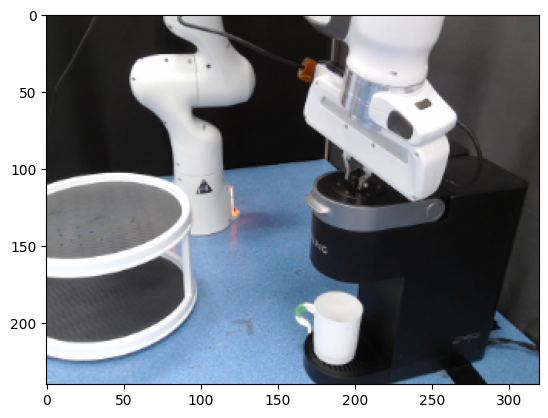

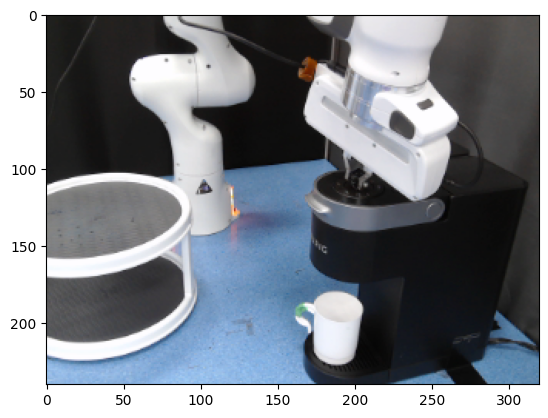

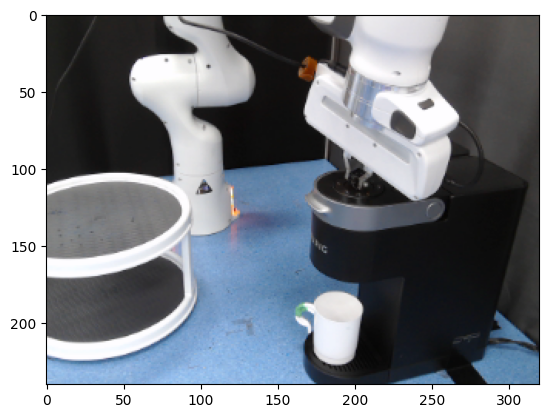

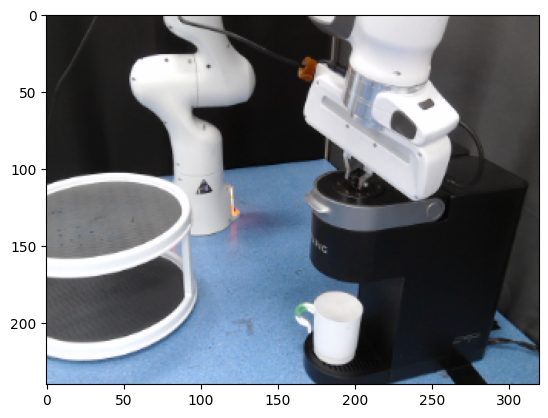

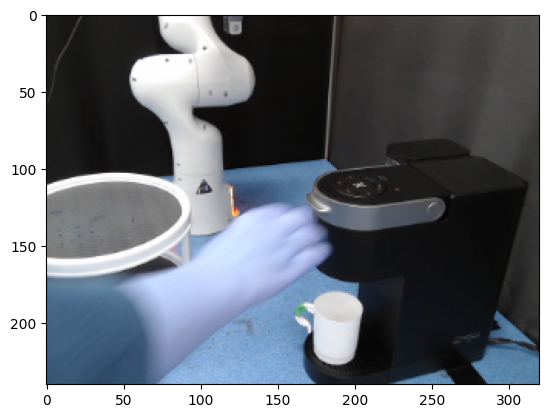

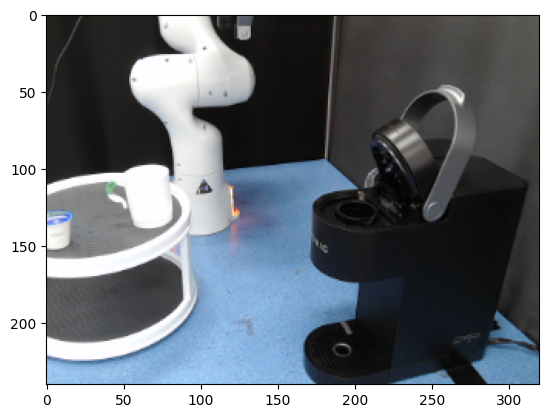

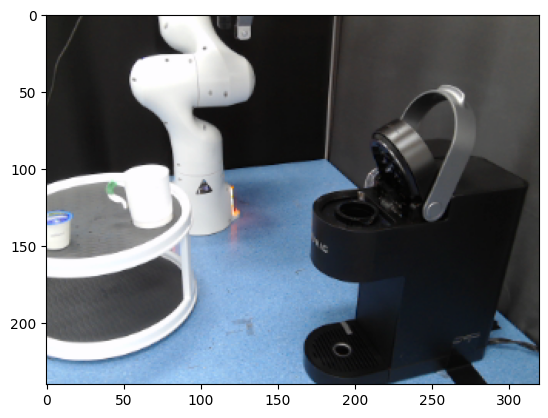

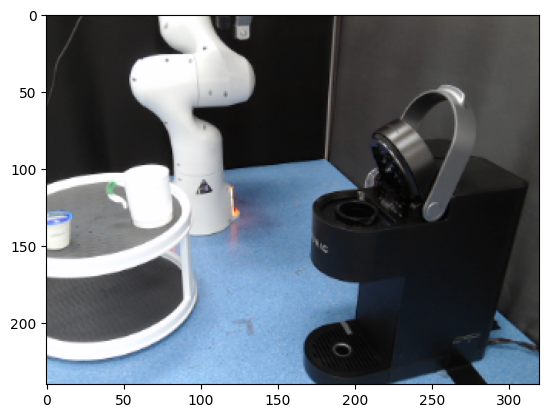

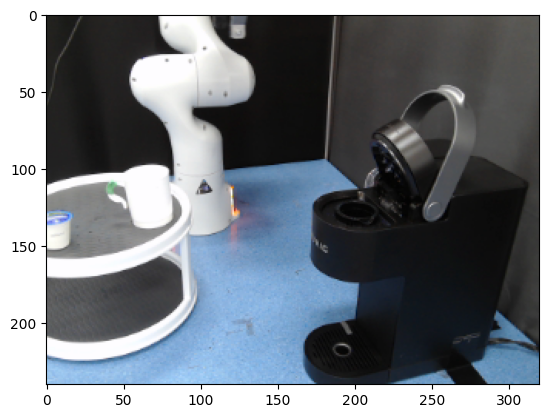

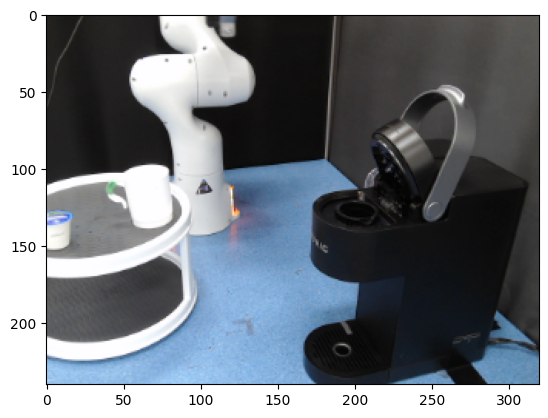

Dataset: taco_play
Episode: episode_0
Image Key: rgb_gripper


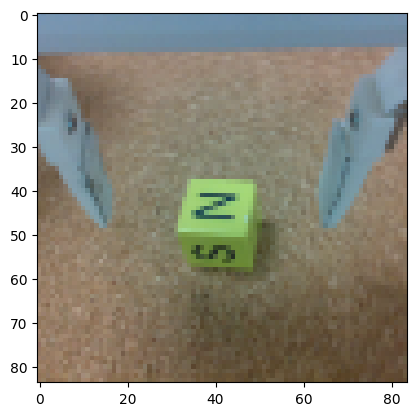

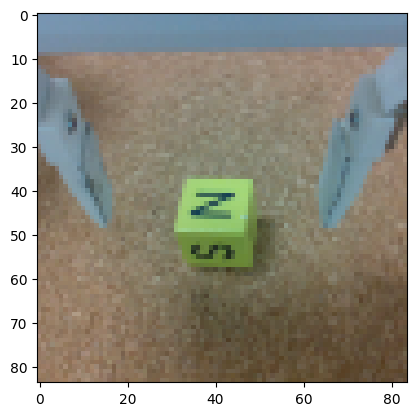

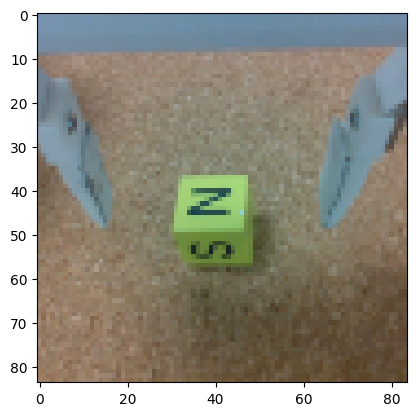

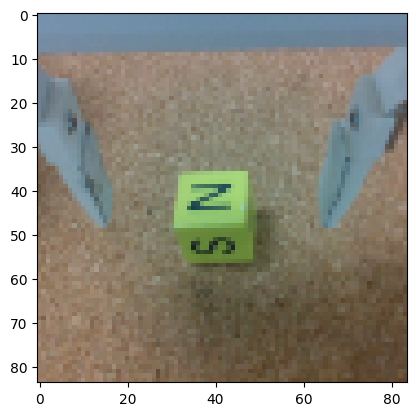

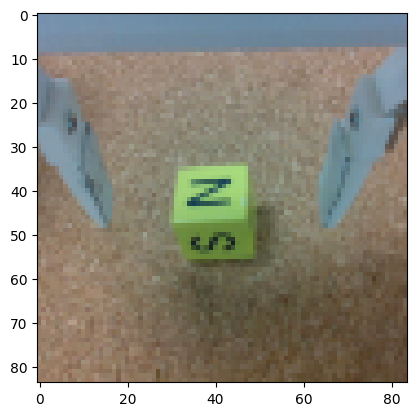

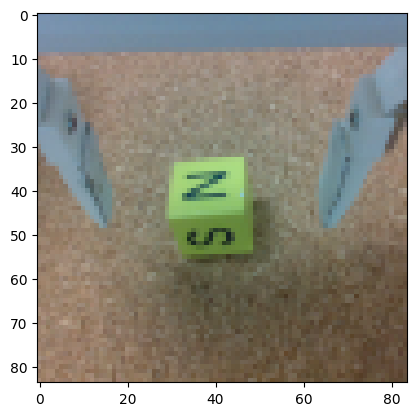

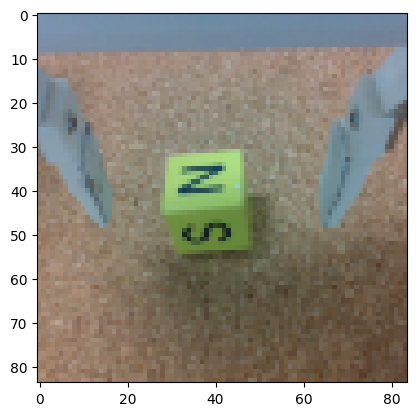

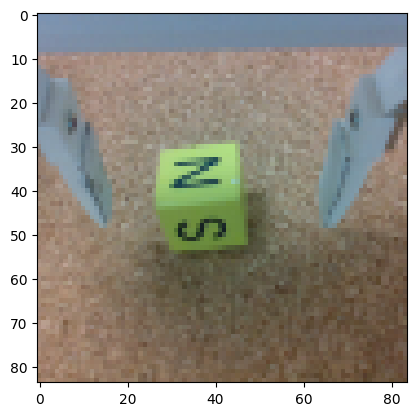

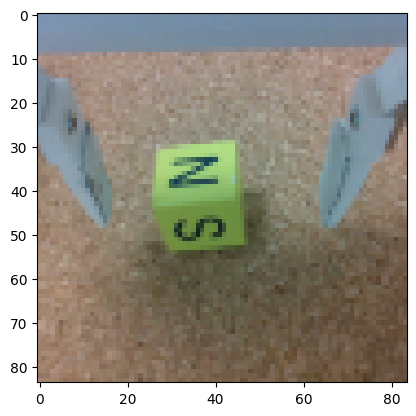

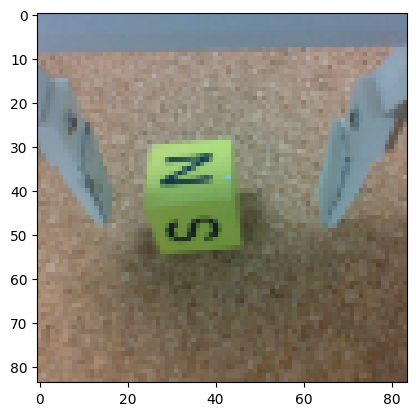

Dataset: taco_play
Episode: episode_0
Image Key: rgb_static


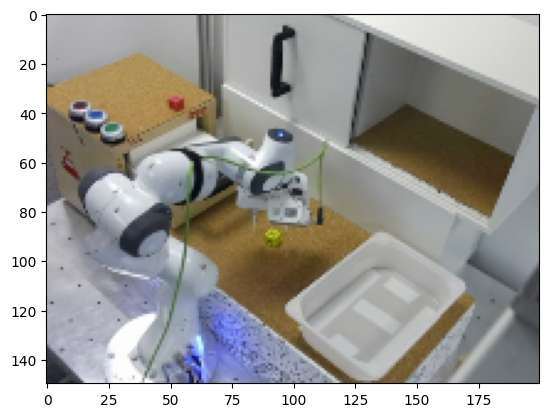

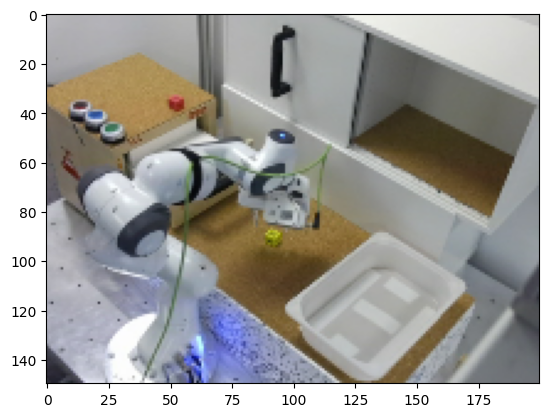

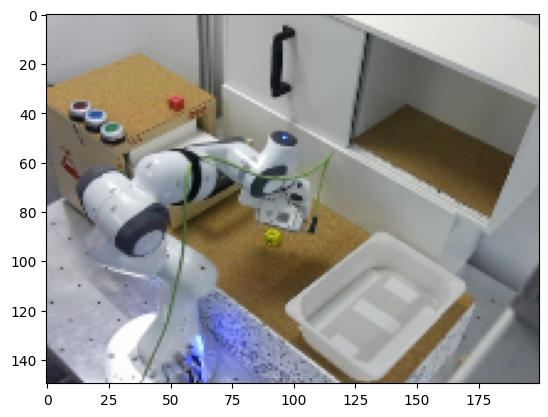

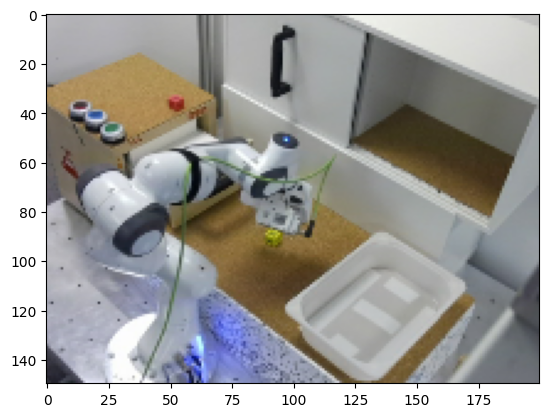

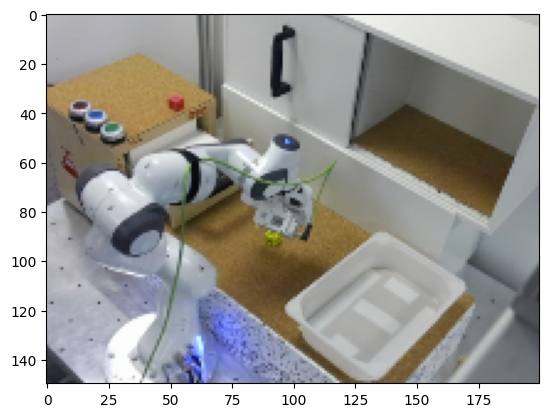

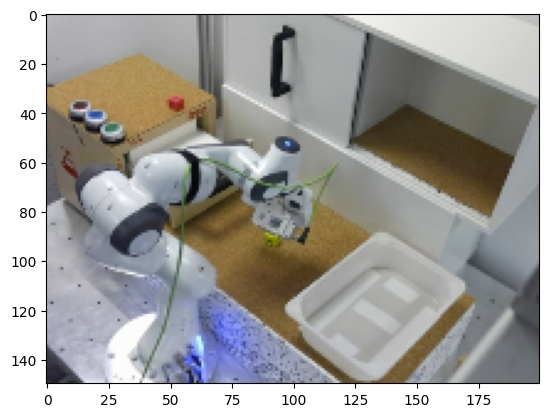

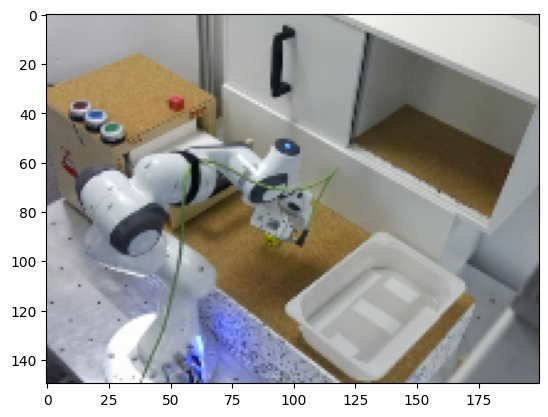

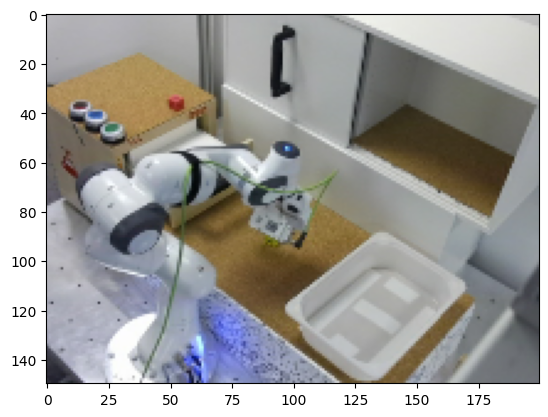

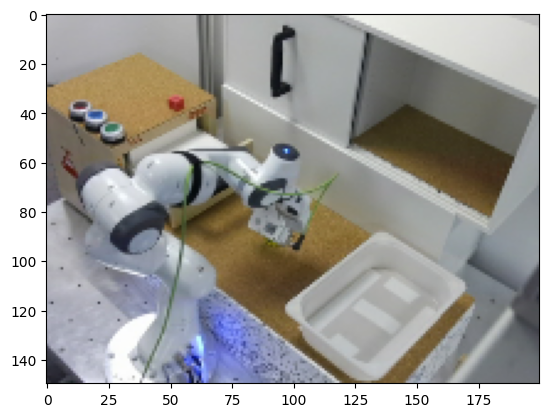

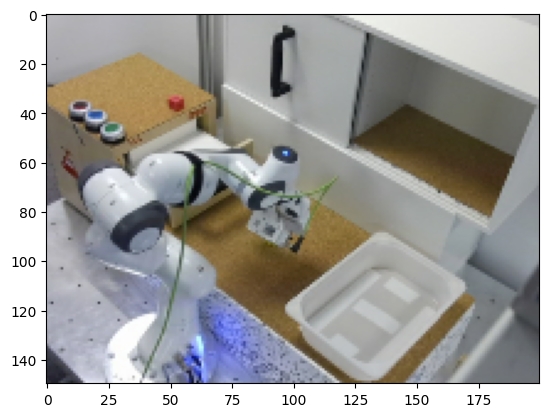

In [174]:
for data_name in data.keys():
    for episode in data[data_name].keys():
        for img_key in data[data_name][episode]["images"].keys():
            images = data[data_name][episode]["images"][img_key]
            
            print(f"Dataset: {data_name}\nEpisode: {episode}\nImage Key: {img_key}")
            for step in range(10):
                img = images[step,:]
                plt.imshow(img)
                plt.show()

In [45]:
print(data.keys())
print(data["nyu_rot_dataset_converted_externally_to_rlds"]["action"].shape)
print(data["ucsd_kitchen_dataset_converted_externally_to_rlds"]["action"].shape)

print(np.percentile(data["nyu_rot_dataset_converted_externally_to_rlds"]["action"], q=1, axis=0))
print(np.percentile(data["ucsd_kitchen_dataset_converted_externally_to_rlds"]["action"], q=1, axis=0))

print(np.percentile(data["nyu_rot_dataset_converted_externally_to_rlds"]["action"], q=99, axis=0))
print(np.percentile(data["ucsd_kitchen_dataset_converted_externally_to_rlds"]["action"], q=99, axis=0))

dict_keys(['nyu_rot_dataset_converted_externally_to_rlds', 'ucsd_kitchen_dataset_converted_externally_to_rlds'])
(40, 7)
(36, 8)
[ 0. -1. -1.  0.  0.  0.  0.]
[ 206.4         -1.         111.7       -179.325      -80.000015
    1.0500025    0.35         0.       ]
[1. 1. 0. 0. 0. 0. 0.]
[ 5.6864948e+02  4.0000000e+02  2.8329999e+02  1.7964998e+02
 -3.4999254e-01  8.5500137e+01  1.0000000e+00  6.5000153e-01]


In [64]:
data["nyu_rot_dataset_converted_externally_to_rlds"]["action"][2:4,:]

array([[ 0., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  0.,  0.,  0.,  0.,  0.]], dtype=float32)

#### Supplementary

In [ ]:
#### save & load data slice - in tensorflow format.
# subset.save(path_data)
# subset = tf.data.Dataset.load(path_data)





################ Load bridge_subset.h5. It has only one dataset.
# with h5py.File(f"{path_data}/bridge_subset.h5", "r") as f:
#     for episode_idx, key in enumerate(f.keys()):
#         grp = f[key]
#         images = grp["images"][:] # shape: (n_steps, image_dim_0, image_dim_1, image_dim_2)
#         rotation_delta_hdf5 = grp["rotation_delta"][:] # shape: (n_steps, 3d)
#         world_vector_hdf5 = grp["world_vector"][:] # shape: (n_steps, 3d)